In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("ai/anomalies/data/sensor_data.csv")
df.head()

,timestamp,device_id,temperature,humidity,gas,presence,expected_scenario
0,2026-10-05T10:00:00Z,esp8266-01,23.98,54.92,119.76,False,normal
1,2026-10-05T10:00:05Z,esp8266-01,24.09,54.57,115.86,False,normal
2,2026-10-05T10:00:10Z,esp8266-01,23.98,55.04,120.56,False,normal
3,2026-10-05T10:00:15Z,esp8266-01,24.15,55.19,123.09,False,normal
4,2026-10-05T10:00:20Z,esp8266-01,24.04,55.57,120.18,False,normal


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   timestamp          1000 non-null   str    
 1   device_id          1000 non-null   str    
 2   temperature        1000 non-null   float64
 3   humidity           1000 non-null   float64
 4   gas                1000 non-null   float64
 5   presence           1000 non-null   bool   
 6   expected_scenario  1000 non-null   str    
dtypes: bool(1), float64(3), str(3)
memory usage: 48.0 KB


In [ ]:
df.describe()

,temperature,humidity,gas
count,1000.000000,1000.000000,1000.000000
mean,24.232010,54.801540,126.577590
std,1.033815,0.962425,26.600915
min,23.400000,49.520000,112.330000
25%,23.850000,54.477500,118.450000
50%,24.040000,54.950000,120.430000
75%,24.200000,55.360000,122.332500
max,31.180000,56.780000,293.030000


In [5]:
# Compte les valeurs manquantes dans chaque colonne.
df.isna().sum()

timestamp            0
device_id            0
temperature          0
humidity             0
gas                  0
presence             0
expected_scenario    0
dtype: int64

In [6]:
# Convertit les dates textuelles en dates UTC exploitables.
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    utc=True,
    errors="coerce",
)

# Uniformise la présence sous forme booléenne True/False.
df["presence"] = (
    df["presence"]
    .astype(str)
    .str.lower()
    .map({"true": True, "false": False})
)

# Supprime les mesures essentielles invalides et trie chronologiquement.
df = (
    df.dropna(
        subset=["timestamp", "temperature", "humidity", "gas"]
    )
    .sort_values("timestamp")
    .reset_index(drop=True)
)

# Vérifie les types obtenus après nettoyage.
df.dtypes

timestamp            datetime64[us, UTC]
device_id                            str
temperature                      float64
humidity                         float64
gas                              float64
presence                            bool
expected_scenario                    str
dtype: object

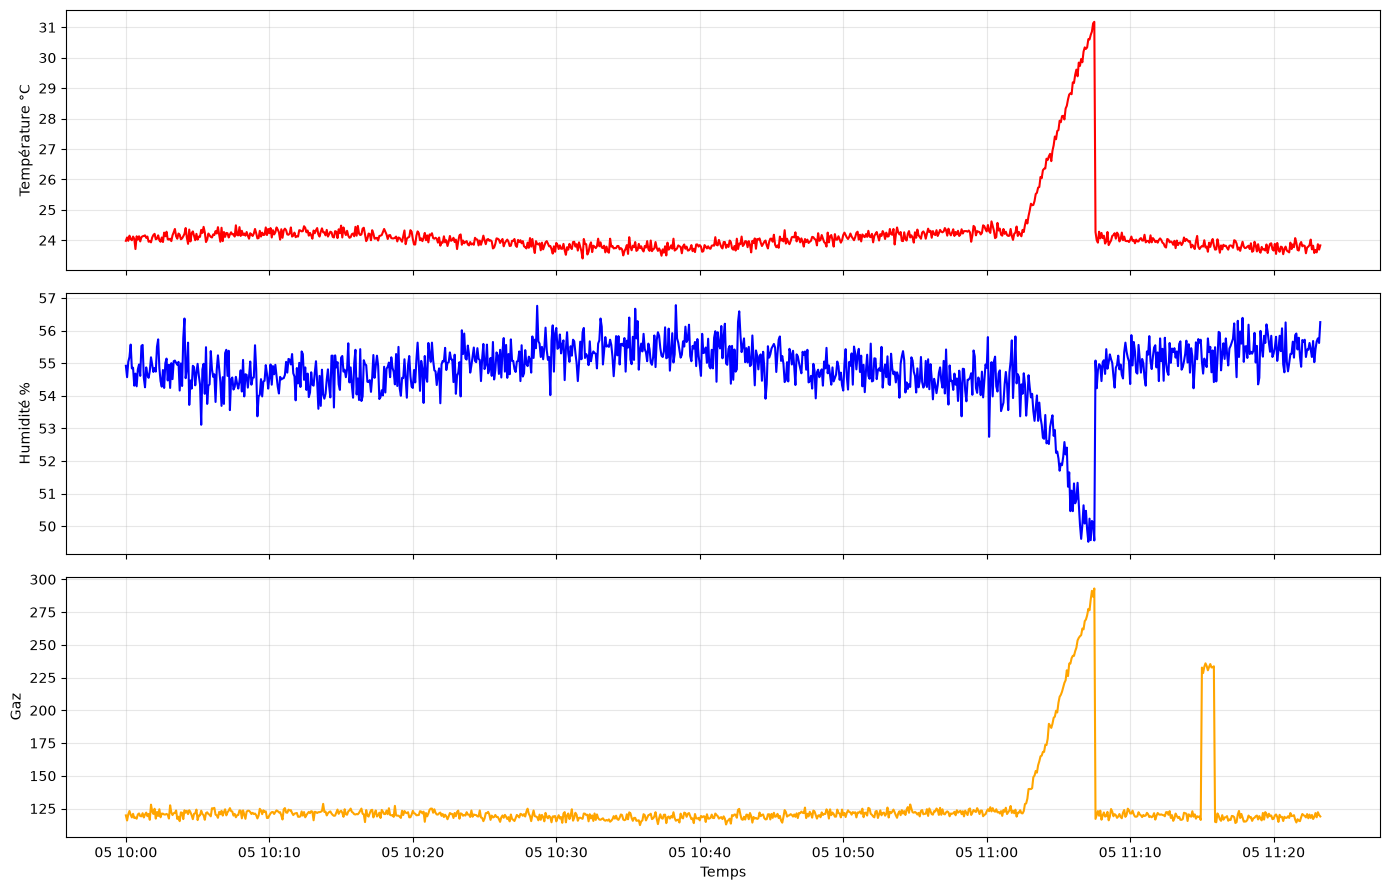

In [7]:
# Crée trois graphiques partageant le même axe temporel.
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(df["timestamp"], df["temperature"], color="red")
axes[0].set_ylabel("Température °C")
axes[0].grid(alpha=0.3)

axes[1].plot(df["timestamp"], df["humidity"], color="blue")
axes[1].set_ylabel("Humidité %")
axes[1].grid(alpha=0.3)

axes[2].plot(df["timestamp"], df["gas"], color="orange")
axes[2].set_ylabel("Gaz")
axes[2].set_xlabel("Temps")
axes[2].grid(alpha=0.3)

# Ajuste les espacements puis affiche la figure.
plt.tight_layout()
plt.show()

In [8]:
# Compte les scénarios connus; cette colonne sert uniquement à évaluer le modèle.
# Elle ne doit jamais être utilisée comme variable d'entrée.
df["expected_scenario"].value_counts()

expected_scenario
normal            928
drift_temp_gas     61
gas_spike          11
Name: count, dtype: int64

In [9]:
# Calcule le délai entre deux mesures successives pour chaque appareil.
df["interval_seconds"] = (
    df.groupby("device_id")["timestamp"]
    .diff()
    .dt.total_seconds()
)

# Vérifie que la fréquence est régulière, environ 5 secondes ici.
df["interval_seconds"].describe()

count    999.0
mean       5.0
std        0.0
min        5.0
25%        5.0
50%        5.0
75%        5.0
max        5.0
Name: interval_seconds, dtype: float64

In [10]:
# Définit les capteurs analysés et une fenêtre glissante de 10 mesures.
SENSORS = ["temperature", "humidity", "gas"]
WINDOW = 10

# Construit des variables temporelles séparément pour chaque appareil.
for sensor in SENSORS:
    grouped = df.groupby("device_id")[sensor]

    # Variation depuis la mesure précédente.
    df[f"{sensor}_delta"] = grouped.diff()

    # Moyenne récente, utile pour repérer une dérive progressive.
    df[f"{sensor}_mean"] = grouped.transform(
        lambda values: values.rolling(WINDOW).mean()
    )

    # Variabilité récente, utile pour repérer un signal instable.
    df[f"{sensor}_std"] = grouped.transform(
        lambda values: values.rolling(WINDOW).std()
    )

    # Vitesse de variation du capteur par seconde.
    df[f"{sensor}_slope"] = (
        df[f"{sensor}_delta"] / df["interval_seconds"]
    )

# Met en évidence une hausse simultanée de température et de gaz.
df["temperature_gas_interaction"] = (
    df["temperature_slope"] * df["gas_slope"]
)

In [11]:
# Remplace les infinis et retire les lignes incomplètes dues à diff/rolling.
df_features = (
    df.replace([np.inf, -np.inf], np.nan)
    .dropna()
    .reset_index(drop=True)
)

# Contrôle le jeu de données désormais prêt pour le modèle.
df_features.head()

,timestamp,device_id,temperature,humidity,gas,presence,expected_scenario,interval_seconds,temperature_delta,temperature_mean,...,temperature_slope,humidity_delta,humidity_mean,humidity_std,humidity_slope,gas_delta,gas_mean,gas_std,gas_slope,temperature_gas_interaction
0,2026-10-05 10:00:45+00:00,esp8266-01,24.13,54.29,117.23,False,normal,5.0,0.42,24.025,...,0.084,-0.39,54.827,0.391920,-0.078,-0.93,119.174,2.124085,-0.186,-0.015624
1,2026-10-05 10:00:50+00:00,esp8266-01,24.02,54.81,120.47,False,normal,5.0,-0.11,24.029,...,-0.022,0.52,54.816,0.390561,0.104,3.24,119.245,2.157453,0.648,-0.014256
2,2026-10-05 10:00:55+00:00,esp8266-01,24.13,54.96,121.25,False,normal,5.0,0.11,24.033,...,0.022,0.15,54.855,0.382659,0.030,0.78,119.784,1.872255,0.156,0.003432
3,2026-10-05 10:01:00+00:00,esp8266-01,23.96,54.61,119.23,False,normal,5.0,-0.17,24.031,...,-0.034,-0.35,54.812,0.383719,-0.070,-2.02,119.651,1.858192,-0.404,0.013736
4,2026-10-05 10:01:05+00:00,esp8266-01,24.10,55.53,119.06,False,normal,5.0,0.14,24.026,...,0.028,0.92,54.846,0.432851,0.184,-0.17,119.248,1.413206,-0.034,-0.000952


In [12]:
# Variables numériques fournies au modèle de détection d'anomalies.
# Les identifiants, dates, présences et réponses attendues sont exclus.
FEATURES = [
    "temperature",
    "humidity",
    "gas",
    "temperature_delta",
    "humidity_delta",
    "gas_delta",
    "temperature_mean",
    "humidity_mean",
    "gas_mean",
    "temperature_std",
    "humidity_std",
    "gas_std",
    "temperature_slope",
    "humidity_slope",
    "gas_slope",
    "temperature_gas_interaction",
]

In [13]:
# Vérifie l'échelle et la distribution de chaque variable préparée.
df_features[FEATURES].describe().T

,count,mean,std,min,25%,50%,75%,max
temperature,991.0,24.233996,1.038228,23.400000,23.850000,24.040000,24.210000,31.180000
humidity,991.0,54.800767,0.966201,49.520000,54.470000,54.950000,55.360000,56.780000
gas,991.0,126.642866,26.711997,112.330000,118.460000,120.430000,122.355000,293.030000
temperature_delta,991.0,0.000121,0.278242,-6.910000,-0.110000,0.000000,0.130000,0.640000
humidity_delta,991.0,0.001594,0.669837,-3.060000,-0.440000,0.000000,0.465000,5.520000
gas_delta,991.0,0.000797,8.274409,-175.950000,-1.890000,0.060000,2.210000,116.350000
temperature_mean,991.0,24.235131,0.990329,23.672000,23.840500,24.042000,24.204500,30.630000
humidity_mean,991.0,54.796902,0.835350,50.010000,54.589000,54.892000,55.276000,55.728000
gas_mean,991.0,126.640920,24.798016,115.994000,118.834000,120.554000,121.686500,278.114000
temperature_std,991.0,0.157390,0.286845,0.044234,0.100377,0.117610,0.139738,3.588290
